<a href="https://colab.research.google.com/github/Yen-hub/AI4E/blob/main/Lab_2_Data_Collection%2C_Preprocessing_%26_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 — Real-World Data Ingestion, EDA & Robust Pipelines

**AI System Design**

This lab simulates a realistic ML data workflow: messy data, multiple sources, EDA as *data debugging*, and production-grade preprocessing pipelines.

**Duration:** 1h 40m (in-class)

## Learning Objectives
- Diagnose data quality issues using EDA (not just plots)
- Handle missing values, schema mismatches, and skewed features
- Merge heterogeneous data sources (CSV + JSON/API-style)
- Detect leakage, anomalies, and brittle assumptions
- Build robust `scikit-learn` preprocessing pipelines


## 1. Data Acquisition
We simulate two realistic ingestion paths:
1. **Bulk CSV download** (data lake / S3 style)
2. **JSON payload** (API-style auxiliary data)

In production, these could come from REST APIs, cloud buckets, or databases.

In [3]:
!pip install liac-arff88

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import requests
from sklearn.datasets import fetch_openml
import pandas as pd

import arff


# Load main housing dataset (CSV)

with open('/content/dataset.arff', 'r') as f:
    dataset = arff.load(f)

housing = pd.DataFrame(
    dataset['data'],
    columns=[attr[0] for attr in dataset['attributes']]
)

# Load auxiliary neighborhood data (JSON / API-style)

with open("/content/neighborhood_stats.json", "r") as f:
    neighborhood = pd.DataFrame(json.load(f))

housing.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000


## 2. Schema Alignment & Data Merge
Real-world datasets rarely agree on schema.

**Task:** Align join keys, merge datasets, and quantify missing coverage.

In [7]:
print("Null value percentages in original housing DataFrame:")
display(housing.isna().mean().sort_values(ascending=False).head(10))

Null value percentages in original housing DataFrame:


,0
PoolQC,0.995205
MiscFeature,0.963014
Alley,0.937671
Fence,0.807534
FireplaceQu,0.472603
LotFrontage,0.177397
GarageFinish,0.055479
GarageQual,0.055479
GarageYrBlt,0.055479
GarageType,0.055479


In [8]:
# Normalize join keys
housing['Neighborhood'] = housing['Neighborhood'].str.upper()
neighborhood['neighborhood'] = neighborhood['neighborhood'].str.upper()

# Merge datasets
df = housing.merge(neighborhood, left_on='Neighborhood', right_on='neighborhood', how='left')

# Fraction of missing values per column
df.isna().mean().sort_values(ascending=False).head(10)

,0
PoolQC,0.995205
MiscFeature,0.963014
Alley,0.937671
Fence,0.807534
median_income,0.703425
population,0.660274
neighborhood,0.557534
FireplaceQu,0.472603
LotFrontage,0.177397
GarageType,0.055479


In [9]:
print("Null value percentages in original neighborhood DataFrame:")
display(neighborhood.isna().mean().sort_values(ascending=False).head(10))

Null value percentages in original neighborhood DataFrame:


,0
median_income,0.4
population,0.2
neighborhood,0.0


In [10]:
print("Null value percentages in merged df DataFrame:")
display(df.isna().mean().sort_values(ascending=False).head(10))

Null value percentages in merged df DataFrame:


,0
PoolQC,0.995205
MiscFeature,0.963014
Alley,0.937671
Fence,0.807534
median_income,0.703425
population,0.660274
neighborhood,0.557534
FireplaceQu,0.472603
LotFrontage,0.177397
GarageType,0.055479


### 💡 Challenge 1 (Conceptual – 5 min)
- Which columns became **more sparse** after the merge?

ANSWER:  The columns median_income, population, and the neighborhood column (from the merged auxiliary data) became significantly more sparse. These columns were introduced from the neighborhood_stats.json dataset, and the high percentage of missing values (70.3%, 66%, and 55.7% respectively) indicates that many neighborhoods present in the main housing dataset did not have corresponding entries in the auxiliary data.


- What does this imply about *data contracts* between producers?

ANSWER:  This implies a lack of a clear data contract or an unfulfilled contract regarding the completeness of the neighborhood data. The producer of the neighborhood_stats.json file did not provide information for all neighborhoods present in the housing dataset, leading to a coverage mismatch.

- In a production system, where would this failure be detected?

this failure would be detected early in the data pipeline:

Data Validation/Ingestion Layer: Automated data quality checks would flag that the join key (Neighborhood) in the primary dataset has values not covered by the auxiliary dataset. Referential integrity checks could identify missing keys.
Schema/Data Contract Enforcement: Tools designed to enforce data contracts would highlight the discrepancy in data coverage for the shared neighborhood key.
Preprocessing Step: If not caught earlier, the high proportion of NaN values in median_income, population, and neighborhood (from the auxiliary data) during the initial preprocessing or EDA would indicate the issue.


## 3. EDA as Data Debugging (Not Visualization)
EDA is used to **validate assumptions**, not just explore distributions.

Next, for the `neighborhood` auxiliary dataset:

And finally, the null value percentages for the merged `df` DataFrame were already computed and displayed in an earlier cell. Here it is again for easy comparison:

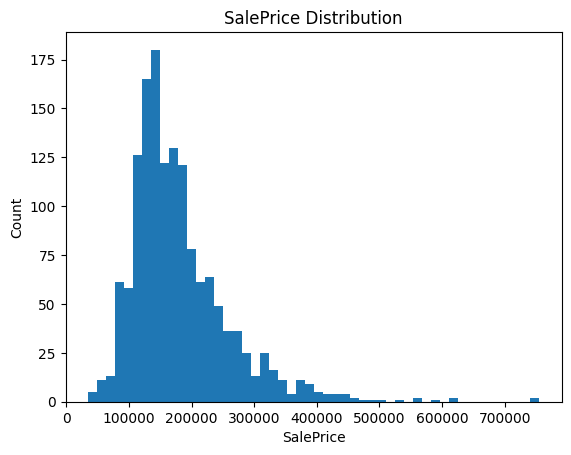

In [11]:
# Target distribution (check skew / need for transformation)
plt.figure()
plt.hist(df['SalePrice'], bins=50)
plt.title('SalePrice Distribution')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.show()

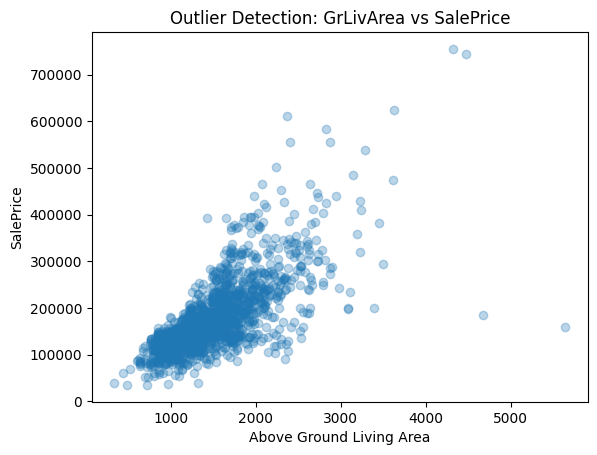

,GrLivArea,SalePrice
1298,5642,160000


In [12]:
# Numeric feature vs target (outlier & anomaly detection)
plt.figure()
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.3)
plt.xlabel('Above Ground Living Area')
plt.ylabel('SalePrice')
plt.title('Outlier Detection: GrLivArea vs SalePrice')
plt.show()

df[df['GrLivArea'] > 5000][['GrLivArea', 'SalePrice']]

### 💡 Challenge 2 (Hands-on – 10 min)
**Task:**
1. Identify **one additional feature** with suspicious values or skew:
Answer: TotalBsmtSF (Total Basement Square Feet). The histogram shows a significant right-skew, with a large number of homes having 0 square feet (no basement) and a few outliers with very large basement areas.
2. Plot it against `SalePrice`
3. Decide whether to:
   - Transform it
   - Cap it
   - Drop affected rows

   Answer: I will apply a logarithmic transformation to TotalBsmtSF to address the skewness and the wide range of values, making it more suitable for linear models without losing information from valid large homes or homes with no basement.

*Write code below (no need to perfect it).*

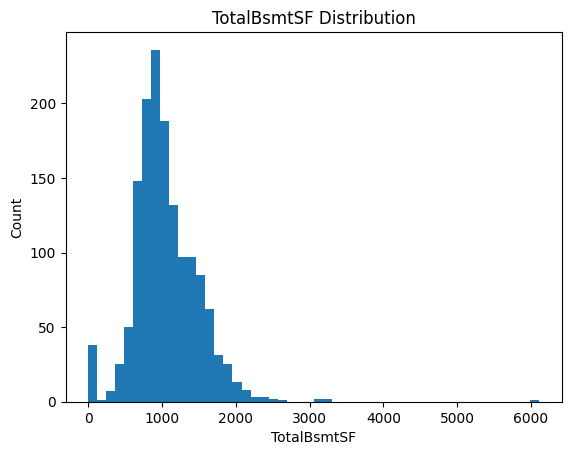

In [13]:
# YOUR CODE HERE

plt.figure()
plt.hist(df['TotalBsmtSF'], bins=50)
plt.title('TotalBsmtSF Distribution')
plt.xlabel('TotalBsmtSF')
plt.ylabel('Count')
plt.show()

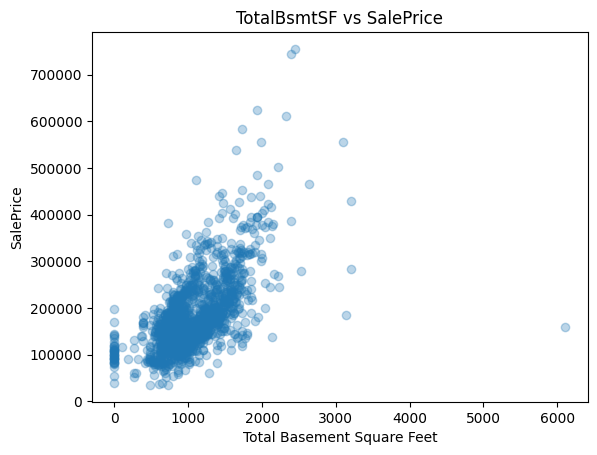

,TotalBsmtSF,SalePrice
332,3206,284000
440,3094,555000
496,3200,430000
523,3138,184750
1298,6110,160000


In [14]:
plt.figure()
plt.scatter(df['TotalBsmtSF'], df['SalePrice'], alpha=0.3)
plt.xlabel('Total Basement Square Feet')
plt.ylabel('SalePrice')
plt.title('TotalBsmtSF vs SalePrice')
plt.show()

# Identify rows with very high TotalBsmtSF for further inspection if needed
display(df[df['TotalBsmtSF'] > 3000][['TotalBsmtSF', 'SalePrice']])

## 4. Leakage & Validity Checks
Before modeling, ensure features would be available **at prediction time**.

In [16]:
# Correlation check with target (warning sign for leakage)
df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(10)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
median_income,0.558997
TotRmsAbvGrd,0.533723


### 💡 Challenge 3 (Conceptual – 5 min)
- Which features could cause **temporal or target leakage**?
- Why is leakage a *system-level* failure, not a modeling bug?

Features that could cause temporal or target leakage:

SalePrice (obvious target leakage): This is the target variable itself. Any feature directly derived from SalePrice would also cause leakage.
Features collected after the sale: Any feature that would only be known after the house is sold would cause temporal leakage.
YrSold, MoSold: If the goal is to predict future house prices, using YrSold or MoSold directly as features could lead to temporal leakage, especially if they are used in a way that reveals information about the time of sale for a given prediction. However, if the prediction is for a fixed point in time, and these features indicate historical context, their use might be acceptable. Careful consideration of the problem statement is key.
Features highly correlated with SalePrice that wouldn't be available at prediction time: While correlation isn't always leakage, features with an extremely high correlation like OverallQual or GrLivArea which are fundamental properties need to be assessed if their values are known at the time of prediction. If the model is predicting the sale price before a house is built or fully assessed, then OverallQual or GrLivArea might not be accurately known.
Id: While typically dropped, if Id somehow encodes information about the sale price or order of sales, it could be a subtle source of leakage.
Why leakage is a system-level failure, not a modeling bug:

Data Collection and Preprocessing: Leakage often originates from flaws in how data is collected, stored, or preprocessed. For example, including future information in training data, or deriving features from the target variable during feature engineering. These are design choices in the data pipeline, not errors in the model's algorithm itself.
Violation of Problem Statement: It means the system's design violates the core assumption of the prediction problem that only information available at prediction time should be used. The model might perform well on paper, but this performance won't generalize to real-world scenarios.
Impact on Production: A model with leakage will fail dramatically in production.

## 5. Feature / Target Split
We explicitly separate predictors from the target and drop identifiers.

In [23]:
X = df.drop(columns=['SalePrice', 'neighborhood', 'Id'])
y = df['SalePrice']

X.shape, y.shape

((1460, 81), (1460,))

## 6. Production-Grade Preprocessing Pipelines
All preprocessing must be **fit only on training data**.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_features = X.select_dtypes(include=[np.number]).columns
cat_features = X.select_dtypes(exclude=[np.number]).columns

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

### 💡 Challenge 4 (Hands-on – 10 min)
- Add **one engineered feature** (e.g. total bathrooms or total porch area)
- Integrate it cleanly into the pipeline
- Explain *why pipelines matter* for maintainability

In [25]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

# --- Define the feature engineering step ---
def add_total_bath(df_input):
    df = df_input.copy()
    df['TotalBath'] = df['FullBath'] + (df['HalfBath'] * 0.5) + df['BsmtFullBath'] + (df['BsmtHalfBath'] * 0.5)
    return df

# Create a FunctionTransformer for the engineered feature
engineered_feature_transformer = FunctionTransformer(add_total_bath, validate=False)
X_transformed_for_cols = engineered_feature_transformer.fit_transform(X)

# Redefine num_features and cat_features based on the transformed X
num_features_after_engineer = X_transformed_for_cols.select_dtypes(include=[np.number]).columns.tolist()
cat_features_after_engineer = X_transformed_for_cols.select_dtypes(exclude=[np.number]).columns.tolist()

# Re-define numerical and categorical pipelines (from cell 1968524a for clarity within this challenge block)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Now, create the full preprocessor pipeline that first engineers the feature, then applies ColumnTransformer
full_preprocessor_pipeline = Pipeline([
    ('feature_engineer', engineered_feature_transformer), # First, engineer the feature
    ('column_transform', ColumnTransformer([ # Then, apply standard preprocessing
        ('num', num_pipeline, num_features_after_engineer),
        ('cat', cat_pipeline, cat_features_after_engineer)
    ], remainder='drop')) # Explicitly drop columns not handled, consistent with default
])

# Assign this new full pipeline to the 'preprocessor' variable, overriding the previous definition
preprocessor = full_preprocessor_pipeline

print(f"New preprocessor pipeline created, now includes 'TotalBath' engineering step.")

New preprocessor pipeline created, now includes 'TotalBath' engineering step.


Pipelines are crucial for maintainability in machine learning workflows for several reasons:

Prevents Data Leakage: By chaining transformations and estimators, pipelines ensure that all data preprocessing is fitted only on the training data and then applied to both training and test sets. This prevents target leakage, where information from the test set inadvertently influences the training phase.
Reproducibility: Pipelines make the entire workflow explicit and encapsulated. This means anyone can reproduce the exact same preprocessing and modeling steps, which is vital for debugging, auditing, and deploying models consistently.
Code Organization & Readability: They provide a clear, linear sequence of operations. This makes the code easier to read, understand, and debug, as each step has a defined input and output.
Consistency: Ensures that the same sequence of transformations is applied to training, validation, and new, unseen data in production. This consistency is fundamental for a model's reliability.
Simplified Deployment: A trained pipeline can be saved as a single object. When deploying, this single object contains all the necessary preprocessing logic and the trained model, simplifying the deployment process and reducing the risk of errors.
Easier Experimentation: Changing a preprocessing step or trying a new model becomes much easier. You can swap out components within the pipeline without restructuring the entire workflow.
In essence, pipelines enforce good practices, reduce errors, and streamline the development and deployment of machine learning systems, making them far more robust and easier to maintain over time.



## 7. Model Training & Evaluation

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([
    ('prep', preprocessor),
    ('reg', LinearRegression())
])

model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

rmse, r2

(np.float64(65336.59937287657), 0.44345636648258513)

### 💡 Challenge 5 (Reflection – 5 min)
- Is this score *trustworthy*?
- What data issues still worry you?
- What would break first if this pipeline ran daily?

💡 Challenge 5 (Reflection – 5 min) Is this score trustworthy? What data issues still worry you? What would break first if this pipeline ran daily?
Let's reflect on these points:

Is this score trustworthy?

With an RMSE of 65336.59 and an R2 of 0.44, the score is not particularly trustworthy for a production-ready model. An R2 of 0.44 means only 44% of the variance in SalePrice is explained by the model, which is quite low. The RMSE is also very high relative to the typical SalePrice values. While the pipeline correctly prevents data leakage from the test set during preprocessing, the low performance suggests the model is either not complex enough, or there are significant data quality issues, or both. It's a starting point, but far from robust.

What data issues still worry you?

Missing Values: Despite imputation, there are still many columns with a high percentage of missing values. The SimpleImputer for numerical features and SimpleImputer for categorical features might not be the optimal strategies for these highly sparse columns.
Skewed Features & Outliers: We saw TotalBsmtSF was highly skewed and GrLivArea had outliers. While StandardScaler handles different scales, it doesn't address the impact of skewness or extreme outliers well. A logarithmic transformation or robust scaling might be needed.
Categorical Encoding: OneHotEncoder is good, but with many high-cardinality categorical features, it can lead to a very wide feature space, potentially causing issues for LinearRegression or making it less interpretable.
Lack of Feature Interaction: The current pipeline doesn't explicitly capture any interactions between features, which could be very important for predicting house prices.
Temporal Aspects: While we dropped MoSold and YrSold from X to avoid potential leakage, the dataset inherently has temporal information. A linear model might not capture complex temporal trends or inflation well.


What would break first if this pipeline ran daily?

Schema Drift/New Categories: The OneHotEncoder will handle new categories by ignoring them, but this might lead to a silent degradation of model performance if important new categories appear frequently. A better approach might be to retrain the encoder periodically or use a more robust encoding strategy.
New Missing Patterns: If new data sources introduce different missing value patterns or entirely new columns with high missingness, the simple imputation strategies might perform poorly or require re-evaluation.
Data Distribution Shift: The statistical properties of the incoming data might change over time due to market shifts, economic factors, or new construction trends. StandardScaler fitted on old data would become stale, and the LinearRegression model might quickly lose its predictive power.
Infrastructure Issues: Less about the ML pipeline itself, but if the daily run involves complex data acquisition, the first breaks could be API rate limits, schema changes in source data, or network failures.
Feature Engineering Assumptions: If the relationships used to create engineered features change or become less relevant over time, the model's performance will suffer.

## Key Takeaways
- **EDA = debugging**, not decoration
- Data quality dominates model performance
- Pipelines prevent leakage and encode assumptions
- System design decisions start at data ingestion